# DGA Target Construction and Local Signal Investigation (V2.5)

This is a diagnostic, not a final k-nearest-neighbour model. It asks whether observations that are close in the supplied DGA feature space tend to share fault_by_rogers labels. It uses standardised raw DGA plus supplied ratios, reports 1/3/5/10-neighbour purity against a 100-permutation null, same-versus-different-label distance overlap, six pairwise class-separation measures, and concrete close cross-label pairs.

No data are changed. No XGBoost tuning is performed.

V2.5 local-signal diagnostic: 300 observations, 10 supplied DGA features.
Features are median-imputed then standardised only so distance is not dominated by CO/CO2 scale. No data values are changed.


,count,proportion
fault_by_rogers,,
Non-determinable,63,0.210000
Normal,87,0.290000
Partial Discharge,76,0.253333
Thermal Fault,74,0.246667



1. Local label consistency: are nearest DGA neighbours assigned the same target more often than chance?


,metric,observed,permutation_mean,permutation_sd,permutation_95th_pct,empirical_one_sided_p,observed_minus_null_mean
0,1-neighbour purity,0.2500,0.2514,0.0225,0.2867,0.5347,-0.0014
1,3-neighbour purity,0.2733,0.2551,0.0131,0.2756,0.0990,0.0182
2,5-neighbour purity,0.2593,0.2553,0.0109,0.2701,0.3861,0.0041
3,10-neighbour purity,0.2567,0.2555,0.0079,0.2687,0.4455,0.0011


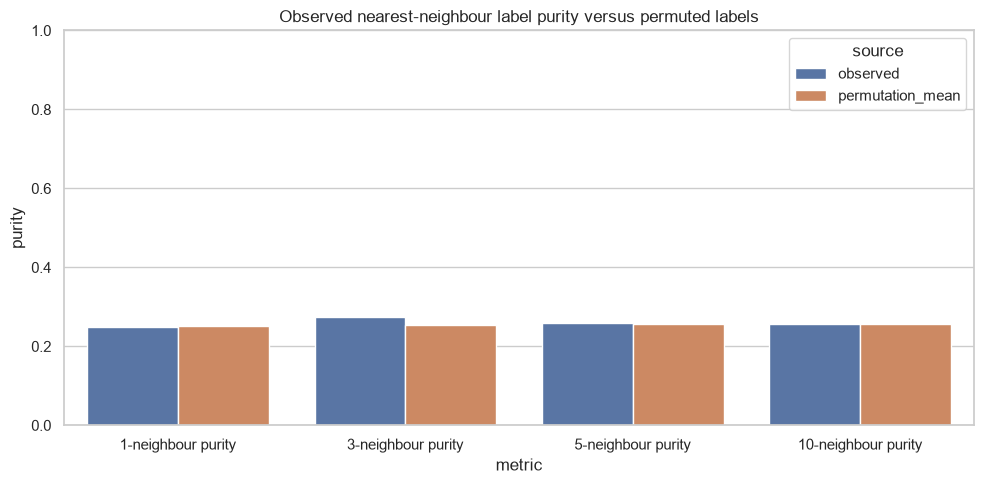


Class-specific local purity


k,1,3,5,10
class,,,,
Non-determinable,0.270,0.228,0.213,0.195
Normal,0.253,0.299,0.301,0.310
Partial Discharge,0.197,0.246,0.234,0.237
Thermal Fault,0.284,0.311,0.276,0.266


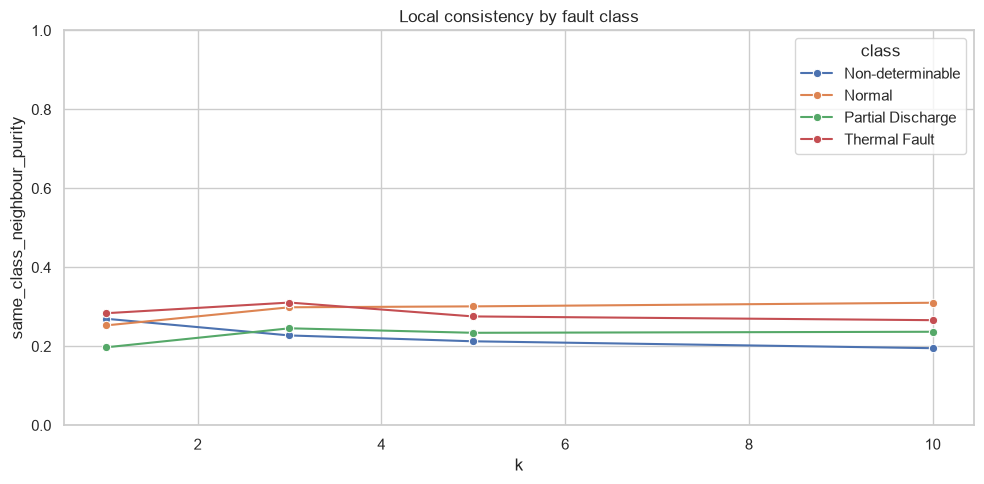


2. Standardised DGA distance: same-label versus different-label observation pairs


,pair_type,n_pairs,mean_distance,median_distance,p05,p95
0,same class,11245,4.3070,4.2050,2.4911,6.4603
1,different class,33605,4.3133,4.2236,2.5023,6.4669


One-sided Mannâ€“Whitney test, same-class distances smaller: p=0.3456. This is descriptive evidence, not a predictive-model result.


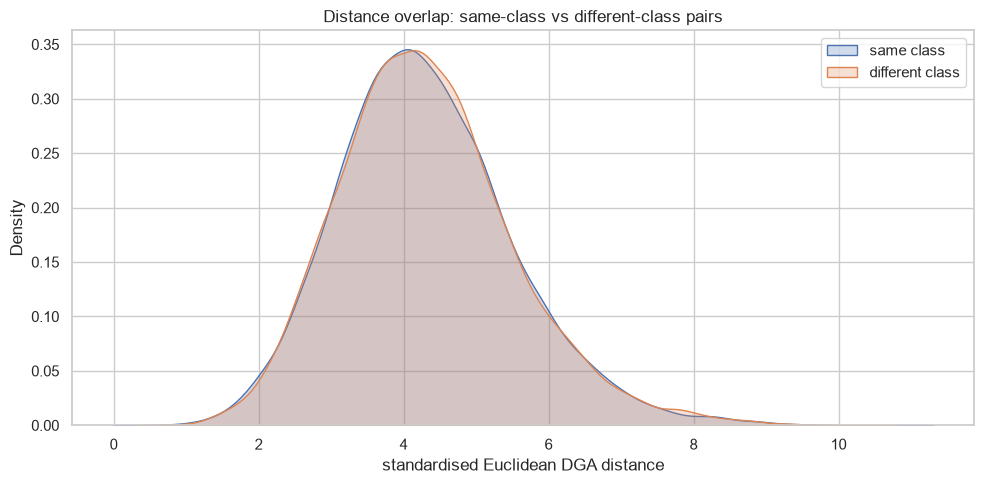


3. Pairwise class separation: centroid distance divided by pooled within-class feature SD


,class_1,class_2,centroid_distance,pooled_feature_sd,standardised_centroid_separation
3,Normal,Partial Discharge,0.2453,1.0032,0.2445
4,Normal,Thermal Fault,0.4364,0.9709,0.4494
0,Non-determinable,Normal,0.4647,1.0287,0.4517
5,Partial Discharge,Thermal Fault,0.4699,0.9822,0.4784
2,Non-determinable,Thermal Fault,0.4899,1.0082,0.4859
1,Non-determinable,Partial Discharge,0.5678,1.0394,0.5463


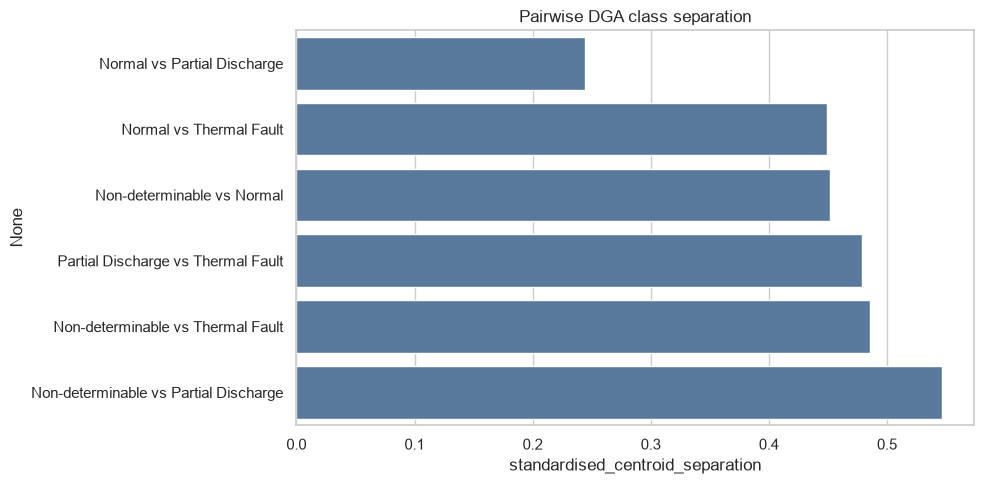


4. Fifteen closest cross-label pairs. Gas columns are pair means for compact display; inspect original row IDs if needed.


,row_a,class_a,row_b,class_b,standardised_distance,H2,C2H2,C2H4,C2H6,CH4,CO,CO2
0,202,Normal,206,Partial Discharge,0.7537,72.238,0.306,85.350,4.493,33.770,515.403,7410.025
1,189,Non-determinable,211,Thermal Fault,0.7599,64.641,0.950,87.121,9.957,14.024,740.874,9549.481
2,4,Non-determinable,6,Thermal Fault,0.8901,43.833,0.485,22.878,16.583,32.014,657.571,8269.556
3,48,Thermal Fault,66,Partial Discharge,0.9239,26.079,0.788,39.336,15.480,42.779,566.333,7778.880
4,117,Normal,154,Thermal Fault,0.9432,37.907,0.363,60.573,14.408,35.067,598.408,7547.417
5,164,Normal,185,Thermal Fault,0.9609,33.599,0.358,74.900,18.924,31.750,529.685,8223.513
6,205,Normal,213,Non-determinable,0.9626,60.703,0.252,93.495,19.714,47.678,538.184,7867.949
7,35,Partial Discharge,50,Normal,0.9821,68.255,0.900,34.044,6.530,20.279,577.900,8444.292
8,238,Partial Discharge,278,Non-determinable,0.9896,52.901,0.834,114.677,16.022,40.292,783.646,7638.148
9,244,Normal,286,Non-determinable,1.0264,40.838,0.261,106.151,18.039,37.356,638.232,8223.424



5. V2.5 local-signal gate


,diagnostic criterion,pass,evidence
0,1-neighbour purity exceeds null 95th percentile,False,0.2500 vs 0.2867; p=0.5347
1,5-neighbour purity exceeds null 95th percentile,False,0.2593 vs 0.2701
2,Same-class distances are lower than different-...,False,Mann-Whitney p=0.3456


V2.5 CONCLUSION
LOCAL SIGNAL NOT ESTABLISHED: nearest DGA neighbours are not more label-coherent than the permutation control. Prioritise target-generation review before V3 tuning.
Provider question: Was fault_by_rogers generated directly from supplied DGA values/ratios, from hidden inputs, or independently? Please provide the target-generation rule and any withheld variables.


In [1]:
%run v25_local_signal_analysis.py